# IPL PREDICTION

## Created By Adarsh patidar

### Start in 14/06/2026

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Phase 1

In [3]:
mdf=pd.read_csv("matches.csv")

In [4]:
ddf=pd.read_csv("deliveries.csv")

In [5]:
mdf.head() 

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
mdf.tail() 

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma
1094,1426312,2024,Chennai,2024-05-26,Final,MA Starc,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,NaN,J Madanagopal,Nitin Menon


In [7]:
mdf["match_type"].value_counts()

match_type
League                1029
Final                   17
Qualifier 1             14
Qualifier 2             14
Eliminator              11
Semi Final               6
Elimination Final        3
3rd Place Play-Off       1
Name: count, dtype: int64

In [8]:
ddf.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [9]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [10]:
ddf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [11]:
mdf.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [12]:
mdf.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [13]:
#low_run_team = mdf.loc[mdf['target_runs'].idxmin()]
#print(f"Sabse kam targeted runs banane wali team: {low_run_team}")

#### We Replace wrong names and save curreent  teams

In [14]:
name_change={
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}

In [15]:
mdf["team1"]=mdf["team1"].replace(name_change)
mdf["team2"]=mdf["team2"].replace(name_change)
mdf["winner"]=mdf["winner"].replace(name_change)
mdf["toss_winner"]=mdf["toss_winner"].replace(name_change)


In [16]:
mdf.shape

(1095, 20)

In [17]:
current_teams=[
    'Mumbai Indians', 'Kolkata Knight Riders', 'Royal Challengers Bangalore',
    'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals',
    'Punjab Kings', 'Sunrisers Hyderabad', 'Lucknow Super Giants', 'Gujarat Titans'
]

In [18]:
mdf = mdf[mdf['team1'].isin(current_teams) & mdf['team2'].isin(current_teams)]

In [19]:
mdf["team1"].unique()

array(['Royal Challengers Bangalore', 'Punjab Kings', 'Delhi Capitals',
       'Mumbai Indians', 'Kolkata Knight Riders', 'Rajasthan Royals',
       'Sunrisers Hyderabad', 'Chennai Super Kings',
       'Lucknow Super Giants', 'Gujarat Titans'], dtype=object)

In [20]:
mdf.shape

(980, 20)

### Cleaning Matches data Frame

In [21]:
mdf.isnull().sum()

id                   0
season               0
city                51
date                 0
match_type           0
player_of_match      4
venue                0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               4
result               0
result_margin       17
target_runs          2
target_overs         2
super_over           0
method             963
umpire1              0
umpire2              0
dtype: int64

In [22]:
mdf["result_margin"]=mdf["result_margin"].fillna(0)

In [23]:
mdf=mdf.dropna(subset=["winner","target_runs","target_overs"])

In [24]:
mdf["city"] = mdf["city"].fillna("Unknown")

In [25]:
mdf.isnull().sum()

id                   0
season               0
city                 0
date                 0
match_type           0
player_of_match      0
venue                0
team1                0
team2                0
toss_winner          0
toss_decision        0
winner               0
result               0
result_margin        0
target_runs          0
target_overs         0
super_over           0
method             959
umpire1              0
umpire2              0
dtype: int64

In [26]:
mdf = mdf.map(lambda x: x.strip() if isinstance(x, str) else x)  # aage piche ki spacing hatane  ke liye

In [27]:
mdf.shape

(976, 20)

### Cleaning Deliveries data Frame

In [28]:
ddf.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


#### We Replace wrong names and save curreent  teams

In [29]:
name_change={
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore'
}

In [30]:
ddf["batting_team"]=ddf["batting_team"].replace(name_change)
ddf["bowling_team"]=ddf["bowling_team"].replace(name_change)

In [31]:
ddf.shape

(260920, 17)

In [32]:
current_teams=[
    'Mumbai Indians', 'Kolkata Knight Riders', 'Royal Challengers Bangalore',
    'Chennai Super Kings', 'Rajasthan Royals', 'Delhi Capitals',
    'Punjab Kings', 'Sunrisers Hyderabad', 'Lucknow Super Giants', 'Gujarat Titans'
]

In [33]:
ddf = ddf[ddf['batting_team'].isin(current_teams) & ddf['bowling_team'].isin(current_teams)]

In [34]:
ddf["batting_team"].unique()

array(['Kolkata Knight Riders', 'Royal Challengers Bangalore',
       'Chennai Super Kings', 'Punjab Kings', 'Rajasthan Royals',
       'Delhi Capitals', 'Mumbai Indians', 'Sunrisers Hyderabad',
       'Lucknow Super Giants', 'Gujarat Titans'], dtype=object)

In [35]:
ddf.shape

(233901, 17)

In [36]:
ddf.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [37]:
ddf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233901 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          233901 non-null  int64 
 1   inning            233901 non-null  int64 
 2   batting_team      233901 non-null  object
 3   bowling_team      233901 non-null  object
 4   over              233901 non-null  int64 
 5   ball              233901 non-null  int64 
 6   batter            233901 non-null  object
 7   bowler            233901 non-null  object
 8   non_striker       233901 non-null  object
 9   batsman_runs      233901 non-null  int64 
 10  extra_runs        233901 non-null  int64 
 11  total_runs        233901 non-null  int64 
 12  extras_type       12784 non-null   object
 13  is_wicket         233901 non-null  int64 
 14  player_dismissed  11626 non-null   object
 15  dismissal_kind    11626 non-null   object
 16  fielder           8414 non-null    object
d

In [38]:
ddf.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.339010e+05,233901.000000,233901.000000,233901.000000,233901.000000,233901.000000,233901.000000,233901.000000
mean,9.216596e+05,1.483936,9.205754,3.626368,1.270991,0.068499,1.339490,0.049705
std,3.765718e+05,0.502745,5.685392,1.816409,1.646469,0.345202,1.633331,0.217335
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483420e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082597e+06,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254094e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [39]:
ddf.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         221117
is_wicket                0
player_dismissed    222275
dismissal_kind      222275
fielder             225487
dtype: int64

In [40]:
ddf = ddf.map(lambda x: x.strip() if isinstance(x, str) else x)

In [41]:
ddf.shape

(233901, 17)

## Data cleaning Complite

In [42]:
H_run_score=ddf.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(5)

In [43]:
H_run_score

batter
V Kohli           7282
S Dhawan          6419
RG Sharma         6235
DA Warner         6003
AB de Villiers    4629
Name: batsman_runs, dtype: int64

In [44]:
Top_win_teams=mdf["winner"].value_counts().head(5)

In [45]:
Top_win_teams

winner
Mumbai Indians                 135
Chennai Super Kings            133
Kolkata Knight Riders          123
Royal Challengers Bangalore    111
Rajasthan Royals               107
Name: count, dtype: int64

In [46]:
toss_decision=mdf["toss_decision"].value_counts()

In [47]:
toss_decision

toss_decision
field    627
bat      349
Name: count, dtype: int64

## Phase 2 Start

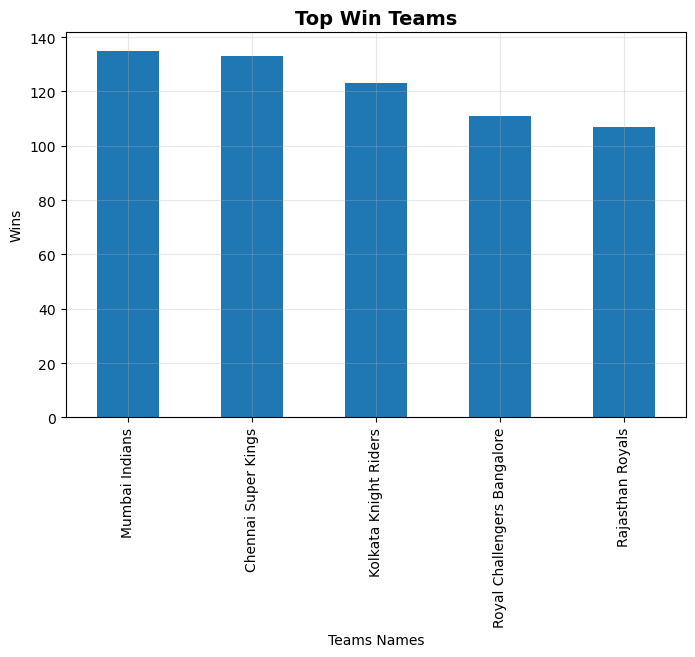

In [48]:

plt.figure(figsize=(8, 5))

Top_win_teams.plot(kind="bar")
plt.title("Top Win Teams",fontsize=14, fontweight='bold')
plt.xlabel("Teams Names")
plt.ylabel("Wins")
plt.grid(alpha=0.3)
plt.show()

### Pie Chart

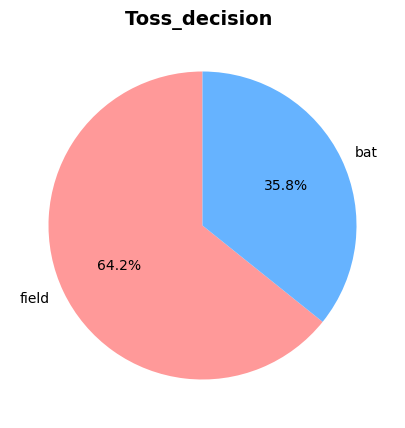

In [49]:
plt.figure(figsize=(8, 5))
colors = ['#ff9999','#66b3ff']
plt.pie(toss_decision,labels=toss_decision.index, autopct='%1.1f%%',startangle=90,colors=colors)
plt.title("Toss_decision ",fontsize=14, fontweight='bold')
plt.show()

### Bar Chart

In [50]:
pom=mdf["player_of_match"].value_counts().head(10)

In [51]:
pom

player_of_match
AB de Villiers    20
RG Sharma         17
CH Gayle          17
DA Warner         16
RA Jadeja         16
AD Russell        15
SR Watson         15
V Kohli           15
KA Pollard        14
MS Dhoni          14
Name: count, dtype: int64

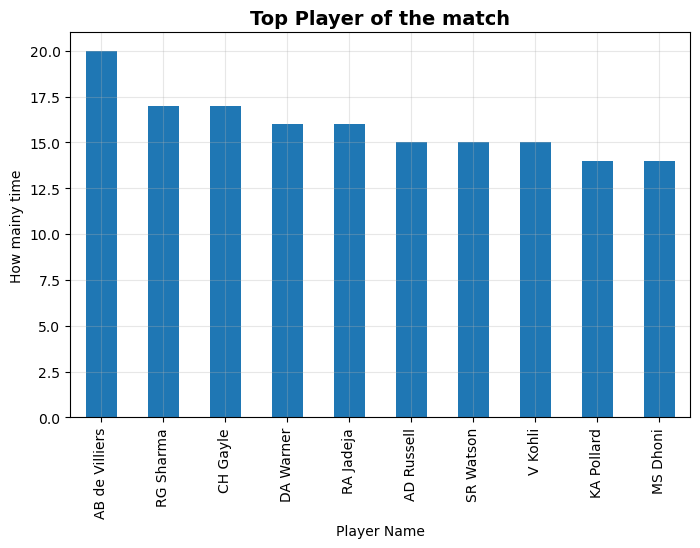

In [52]:
plt.figure(figsize=(8, 5))

pom.plot(kind="bar")
plt.title("Top Player of the match",fontsize=14, fontweight='bold')
plt.xlabel("Player Name")
plt.ylabel("How mainy time")
plt.grid(alpha=0.3)
plt.show()

### Scatter Plot 

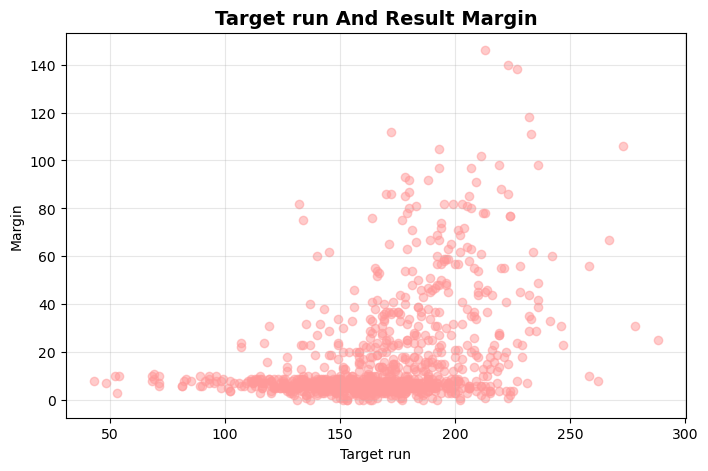

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(mdf["target_runs"],mdf["result_margin"], alpha=0.5, color='#ff9999')
plt.title("Target run And Result Margin",fontsize=14, fontweight='bold')
plt.xlabel("Target run")
plt.ylabel("Margin")
plt.grid(alpha=0.3)
plt.show()

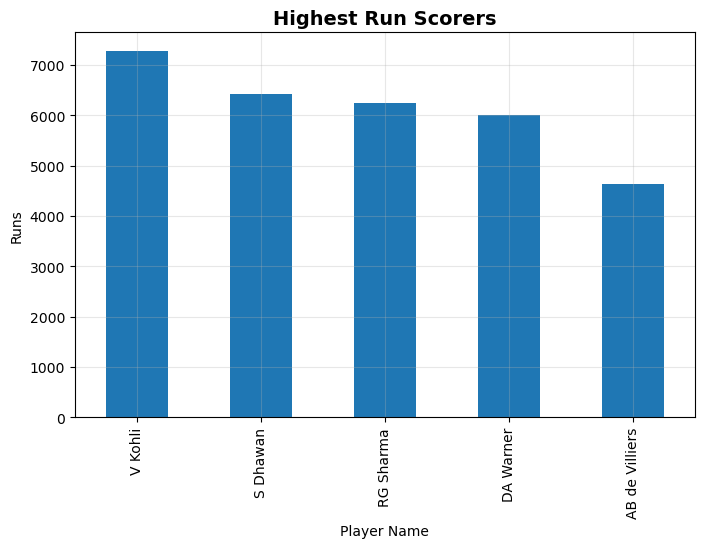

In [54]:


plt.figure(figsize=(8, 5))

H_run_score.plot(kind="bar")
plt.title("Highest Run Scorers",fontsize=14, fontweight='bold')
plt.xlabel("Player Name")
plt.ylabel("Runs")
plt.grid(alpha=0.3)
plt.show()

# Phase 3 ML 

In [55]:
team_avg_score = ddf.groupby("batting_team")["total_runs"].mean()

In [56]:
mdf["team1_avg_score"] = mdf["team1"].map(team_avg_score)

mdf["team2_avg_score"] = mdf["team2"].map(team_avg_score)
mdf[["team1","team1_avg_score"]].head()

,team1,team1_avg_score
0,Royal Challengers Bangalore,1.345029
1,Punjab Kings,1.347704
2,Delhi Capitals,1.314974
3,Mumbai Indians,1.351149
4,Kolkata Knight Riders,1.334891


In [57]:
team_avg_wickets = ddf.groupby("bowling_team")["is_wicket"].mean()

In [58]:
mdf["team1_avg_wickets"] = mdf["team1"].map(team_avg_wickets)

mdf["team2_avg_wickets"] = mdf["team2"].map(team_avg_wickets)


In [59]:
win_pct = (
    mdf["winner"]
    .value_counts(normalize=True)
)

In [60]:
mdf["team1_win_pct"] = mdf["team1"].map(win_pct)

mdf["team2_win_pct"] = mdf["team2"].map(win_pct)


In [61]:
mdf[
[
"team1",
"team2",
"team1_avg_score",
"team2_avg_score",
"team1_avg_wickets",
"team2_avg_wickets",
"team1_win_pct",
"team2_win_pct"
]
].head()


,team1,team2,team1_avg_score,team2_avg_score,team1_avg_wickets,team2_avg_wickets,team1_win_pct,team2_win_pct
0,Royal Challengers Bangalore,Kolkata Knight Riders,1.345029,1.334891,0.048998,0.049251,0.113730,0.126025
1,Punjab Kings,Chennai Super Kings,1.347704,1.352100,0.048127,0.051917,0.106557,0.136270
2,Delhi Capitals,Rajasthan Royals,1.314974,1.326525,0.050365,0.048185,0.108607,0.109631
3,Mumbai Indians,Royal Challengers Bangalore,1.351149,1.345029,0.050666,0.048998,0.138320,0.113730
4,Kolkata Knight Riders,Sunrisers Hyderabad,1.334891,1.318514,0.049251,0.048601,0.126025,0.107582


In [62]:
X = mdf[
[
"season",
"city",
"match_type",
"team1",
"team2",
"toss_winner",
"toss_decision",
"venue",

"team1_avg_score",
"team2_avg_score",

"team1_avg_wickets",
"team2_avg_wickets",

"team1_win_pct",
"team2_win_pct"
]
]

y = mdf["winner"]


In [63]:
categorical_cols = [
"season",
"city",
"match_type",
"team1",
"team2",
"toss_winner",
"toss_decision",
"venue"
]

numeric_cols = [
"team1_avg_score",
"team2_avg_score",
"team1_avg_wickets",
"team2_avg_wickets",
"team1_win_pct",
"team2_win_pct"
]


In [64]:
# Pipe line

In [65]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_cols
    ),
    (
        "num",
        StandardScaler(),
        numeric_cols
    )
])

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
## Logistic Regression Pipeline

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [69]:
lr_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

In [70]:
lr_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
# Decision Tree Pipeline

In [72]:
from sklearn.tree import DecisionTreeClassifier
dt_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeClassifier(
        max_depth=10,
        random_state=42))
])

In [73]:
dt_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)



,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
print("Train Accuracy:", rf_pipeline.score(X_train, y_train))
print("Test Accuracy :", rf_pipeline.score(X_test, y_test))


Train Accuracy: 0.5948717948717949
Test Accuracy : 0.5714285714285714


## Accuracy Compare

In [76]:
from sklearn.metrics import accuracy_score


In [77]:
y_pred=lr_pipeline.predict(X_test)
lr_pred=accuracy_score(y_test,y_pred)
print("LogisticRegression :- ",lr_pred)

LogisticRegression :-  0.5255102040816326


In [78]:
y_pred=dt_pipeline.predict(X_test)
dt_pred=accuracy_score(y_test,y_pred)
print("DecisionTreeClassifier :-",dt_pred)

DecisionTreeClassifier :- 0.5


In [79]:
y_pred=rf_pipeline.predict(X_test)
rf_pred=accuracy_score(y_test,y_pred)
print("RandomForestClassifier :- ",rf_pred)

RandomForestClassifier :-  0.5714285714285714


In [80]:
train_acc = rf_pipeline.score(X_train, y_train)
test_acc = rf_pipeline.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.5948717948717949
Test Accuracy: 0.5714285714285714


In [81]:
# Random forast is best

In [82]:
#Classification Report

In [83]:
from sklearn.metrics import classification_report
y_pred=rf_pipeline.predict(X_test)
cl_report=classification_report(y_test,y_pred)
print("classification_report:- ",cl_report)


classification_report:-                               precision    recall  f1-score   support

        Chennai Super Kings       0.59      0.96      0.73        27
             Delhi Capitals       0.70      0.33      0.45        21
             Gujarat Titans       0.67      0.33      0.44         6
      Kolkata Knight Riders       0.71      0.68      0.69        25
       Lucknow Super Giants       0.00      0.00      0.00         5
             Mumbai Indians       0.59      0.85      0.70        27
               Punjab Kings       0.39      0.33      0.36        21
           Rajasthan Royals       0.46      0.52      0.49        21
Royal Challengers Bangalore       0.62      0.59      0.60        22
        Sunrisers Hyderabad       0.46      0.29      0.35        21

                   accuracy                           0.57       196
                  macro avg       0.52      0.49      0.48       196
               weighted avg       0.56      0.57      0.54       196



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [84]:
# Confusion Matrix

In [85]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[26  0  0  0  0  1  0  0  0  0]
 [ 2  7  0  1  0  0  4  2  2  3]
 [ 2  0  2  0  0  0  0  2  0  0]
 [ 1  1  0 17  0  1  1  0  4  0]
 [ 1  0  1  1  0  1  0  1  0  0]
 [ 4  0  0  0  0 23  0  0  0  0]
 [ 3  0  0  2  0  3  7  4  1  1]
 [ 2  0  0  2  0  4  1 11  0  1]
 [ 1  1  0  0  0  2  2  1 13  2]
 [ 2  1  0  1  0  4  3  3  1  6]]


In [86]:
# Cross Validation

In [87]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(rf_pipeline,X,y,cv=10)

In [88]:
print(scores)
print("Mean Accuracy =", scores.mean())

[0.53061224 0.5        0.53061224 0.58163265 0.58163265 0.57142857
 0.46391753 0.46391753 0.49484536 0.6185567 ]
Mean Accuracy = 0.5337155480749001


In [89]:
# 

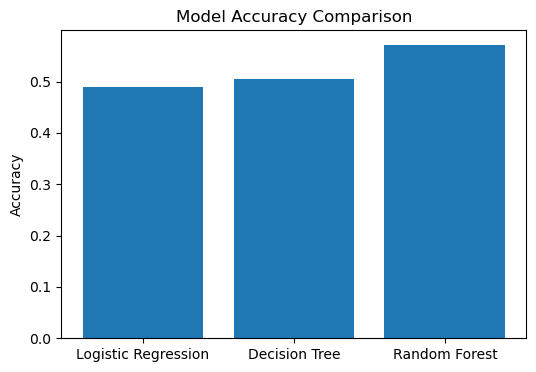

In [90]:
models = ["Logistic Regression","Decision Tree","Random Forest"]
acc = [0.4898,0.5051,0.5714]

plt.figure(figsize=(6,4))
plt.bar(models,acc)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [91]:
# Enter Team 1: Royal Challengers Bangalore Enter Team 2: Gujarat Titans Enter City: Ahmedabad Enter Venue: Narendra Modi Stadium, Ahmedabad Enter Toss Winner: Royal Challengers Bangalore Enter Toss Decision (bat/field): field Enter Season: 2026 Enter Match Type (League/Final): Final

In [92]:
print(sorted(mdf["venue"].unique()))
print()
print(sorted(mdf["city"].unique()))
print()

['Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi', 'Barabati Stadium', 'Barsapara Cricket Stadium, Guwahati', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium', 'Brabourne Stadium, Mumbai', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr DY Patil Sports Academy, Mumbai', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Eden Gardens, Kolkata', 'Feroz Shah Kotla', 'Himachal Pradesh Cricket Association Stadium', 'Himachal Pradesh Cricket Association Stadium, Dharamsala', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'M Chinnaswamy Stadium, Bengaluru', 'M.Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'MA Chidambaram Stadium, Chepauk', 'MA Chidambaram Stadium, Chepauk, Chennai', 'Maharaja Yadavindra Singh International Cricket Sta

In [116]:
teams =sorted(mdf["team1"].unique())
for i, team in enumerate(teams):
    print(i, ":", team)

team1 = input("Enter Team 1 exactly as shown: ")

while team1 not in teams:
    print("❌ Invalid Team Name")
    print("Available Teams:", teams)
    team1 = input("Enter Team 1 Again: ")
print()    

team2 = input("Enter Team 2 exactly as shown: ")
while team2 not in teams:
    print("❌ Invalid Team Name")
    print("Available Teams:", teams)
    team2 = input("Enter Team 2 Again: ")

citys = sorted(mdf["city"].unique())
city = input("Enter City: ")
while city not in citys:
    print("❌ Invalid city Name")
    city = input("Enter city name Again: ")

venues = sorted(mdf["venue"].unique())
venue = input("Enter Venue: ")
while venue not in venues:
    print("❌ Invalid venue Name")
    venue = input("Enter venue name Again: ")

toss_winner = input("Enter Toss Winner: ")
toss_decision = input("Enter Toss Decision (bat/field): ")
season = input("Enter Season: ")

match_types= sorted(mdf["match_type"].unique())

print()
for i, match_type in enumerate(match_types):
    print(i, ":", match_type)
match_type = input("Enter Match Type (League/Final): ")


0 : Chennai Super Kings
1 : Delhi Capitals
2 : Gujarat Titans
3 : Kolkata Knight Riders
4 : Lucknow Super Giants
5 : Mumbai Indians
6 : Punjab Kings
7 : Rajasthan Royals
8 : Royal Challengers Bangalore
9 : Sunrisers Hyderabad


Enter Team 1 exactly as shown:  


❌ Invalid Team Name
Available Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


Enter Team 1 Again:  


❌ Invalid Team Name
Available Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


Enter Team 1 Again:  Rajasthan Royals


Enter Team 2 exactly as shown:  Gujarat Titans
Enter City:  Chandigarh
Enter Venue:  Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur
Enter Toss Winner:  Rajasthan Royals
Enter Toss Decision (bat/field):  bat
Enter Season:  2026


0 : 3rd Place Play-Off
1 : Elimination Final
2 : Eliminator
3 : Final
4 : League
5 : Qualifier 1
6 : Qualifier 2
7 : Semi Final


Enter Match Type (League/Final):  Qualifier 2


In [117]:
team1_avg_score = mdf[mdf["team1"] == team1]["team1_avg_score"].mean()
team2_avg_score = mdf[mdf["team2"] == team2]["team2_avg_score"].mean()

team1_avg_wickets = mdf[mdf["team1"] == team1]["team1_avg_wickets"].mean()
team2_avg_wickets = mdf[mdf["team2"] == team2]["team2_avg_wickets"].mean()

team1_win_pct = win_pct[team1]
team2_win_pct = win_pct[team2]


In [118]:
sample_match = pd.DataFrame({
    "season": [season],
    "city": [city],
    "match_type": [match_type],
    "team1": [team1],
    "team2": [team2],
    "toss_winner": [toss_winner],
    "toss_decision": [toss_decision],
    "venue": [venue],
    "team1_avg_score": [team1_avg_score],
    "team2_avg_score":[team2_avg_score],
    "team1_avg_wickets":[team1_avg_wickets],
    "team2_avg_wickets":[team2_avg_wickets],
    "team1_win_pct" :[team1_win_pct],
    "team2_win_pct" :[team2_win_pct],
    
})

In [119]:
probs = rf_pipeline.predict_proba(sample_match)[0]

winner_index = probs.argmax()

print("Predicted Winner:", rf_pipeline.classes_[winner_index])
print("Confidence:", round(probs[winner_index]*100,2), "%")

Predicted Winner: Rajasthan Royals
Confidence: 18.9 %


In [121]:
print(X.columns.tolist())

['season', 'city', 'match_type', 'team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'team1_avg_score', 'team2_avg_score', 'team1_avg_wickets', 'team2_avg_wickets', 'team1_win_pct', 'team2_win_pct']


In [122]:
import joblib

joblib.dump(rf_pipeline, "rf_pipeline.pkl")

['rf_pipeline.pkl']

In [123]:
import os

print("rf_pipeline.pkl" in os.listdir())

True


In [124]:
pip install streamlit joblib

Note: you may need to restart the kernel to use updated packages.


In [125]:
mdf.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2',
 'team1_avg_score',
 'team2_avg_score',
 'team1_avg_wickets',
 'team2_avg_wickets',
 'team1_win_pct',
 'team2_win_pct']